In [1]:

# 1. Clone the ML4SCI/CMS repository
!git clone https://github.com/ML4SCI/CMS.git

# 2. Navigate to the specific Hybrid Transformer project directory
%cd CMS/MAEs/Hybrid_Transformer_Thanh_Nguyen

# 3. Install required libraries
!pip install lgatr uproot awkward tqdm vector

Cloning into 'CMS'...
remote: Enumerating objects: 751, done.
remote: Counting objects: 100% (130/130), done.
remote: Compressing objects: 100% (99/99), done.
remote: Total 751 (delta 39), reused 83 (delta 27), pack-reused 621 (from 2)
Receiving objects: 100% (751/751), 330.16 MiB | 18.70 MiB/s, done.
Resolving deltas: 100% (187/187), done.
Updating files: 100% (531/531), done.
/content/CMS/MAEs/Hybrid_Transformer_Thanh_Nguyen
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.2/401.2 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 974.8/974.8 kB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.3/689.3 kB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.7/182.7 kB 23.0 MB/s eta 0:00:00


In [2]:
# --- Default libraries ---
import os
import warnings
from pathlib import Path

# --- Working directory ---
PROJECT_DIR = Path().resolve()
PROJECT_ROOT_NAME = 'Hybrid_Transformer_Thanh_Nguyen'

while PROJECT_DIR.name != PROJECT_ROOT_NAME and PROJECT_DIR != PROJECT_DIR.parent:
    PROJECT_DIR = PROJECT_DIR.parent

if Path().resolve() != PROJECT_DIR:
    os.chdir(PROJECT_DIR)

DATA_DIR = PROJECT_DIR / 'data'
LOG_DIR = PROJECT_DIR / 'logs'

# --- Data preprocessing & visualization ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# --- Deep learning ---
import torch

# --- Custom modules ---
from src.configs import LorentzParTConfig, TrainConfig
from src.engine import MaskedModelTrainer, Trainer
from src.models import LorentzParT
from src.utils import accuracy_metric_ce, set_seed
from src.utils.data import JetClassDataset, compute_norm_stats, read_file
from src.utils.viz import *

# --- Settings ---
warnings.filterwarnings('ignore')
set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [ ]:
'''
drive_dest_folder = '/content/drive/MyDrive/GSOC/dara'
drive_dest_path = os.path.join(drive_dest_folder, out_file)

# Create the directory if it doesn't exist
if not os.path.exists(drive_dest_folder):
    os.makedirs(drive_dest_folder)
    print(f"Created directory: {drive_dest_folder}")

# 3. Move the verified file to Drive
if os.path.exists(out_file):
    print(f"Moving {out_file} to Google Drive...")
    shutil.move(out_file, drive_dest_path)
    print(f"File successfully moved to: {drive_dest_path}")
else:
    print("Source file not found. Check if the download was successful.")''''

#Loading Dpendencies

In [4]:
from typing import List, Tuple, Dict, Optional

import torch
from torch import nn, Tensor
from lgatr.interface import extract_vector
from lgatr.layers import EquiLinear

from src.models.classifier import ClassAttentionBlock, Classifier
from src.models.feedforward import Feedforward
from src.models.particle_transformer import ParticleAttentionBlock
from src.models.processor import InteractionEmbedding, ParticleProcessor
from src.configs import LorentzParTConfig
from lgatr.interface import extract_vector
from lgatr.layers import EquiLinear




#Data Preparation

In [3]:
import os
from pathlib import Path
import numpy as np
from sklearn.model_selection import train_test_split
from src.utils.data import JetClassDataset, compute_norm_stats

# --- 1. Mount Google Drive (If not already done) ---
from google.colab import drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- 2. Locate and Load the Compressed Archive ---
DRIVE_FILE_PATH = '/content/drive/MyDrive/GSOC/dara/jetclass_balanced_1M.npz'

print("=" * 70)
print(f"LOADING SERIALIZED ARRAYS FROM DRIVE")
print("=" * 70)

if os.path.exists(DRIVE_FILE_PATH):
    # Load using memory-mapping for high-speed indexing
    data_archive = np.load(DRIVE_FILE_PATH, mmap_mode='r')

    X_particles = data_archive['X_particles']
    X_jets      = data_archive['X_jets']
    y           = data_archive['Y']

    print("SUCCESS: Data loaded cleanly into RAM!")
    print(f"  -> X_particles matrix shape : {X_particles.shape}")
    print(f"  -> X_jets matrix shape      : {X_jets.shape}")
    print(f"  -> y (Labels) matrix shape  : {y.shape}")
    print("=" * 70 + "\n")
else:
    raise FileNotFoundError(f"ERROR: Could not find the file at {DRIVE_FILE_PATH}")

# --- 3. Split the Balanced Dataset Safely ---
# We enforce stratify=y to lock in your strict 10% balance across all splits
X_train, X_val, y_train, y_val = train_test_split(X_particles, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_val, y_val, test_size=0.5, random_state=42, stratify=y_val)

# --- 4. Re-Initialize JetClass Dataset Objects ---
normalize = [True, False, False, True]
norm_dict = compute_norm_stats(X_train)

train_dataset = JetClassDataset(X_train, y_train, normalize, norm_dict, mask_mode='biased')
val_dataset   = JetClassDataset(X_val, y_val, normalize, norm_dict, mask_mode='biased')
test_dataset  = JetClassDataset(X_test, y_test, normalize, norm_dict, mask_mode='first')

Mounted at /content/drive
LOADING SERIALIZED ARRAYS FROM DRIVE
SUCCESS: Data loaded cleanly into RAM!
  -> X_particles matrix shape : (1000000, 4, 128)
  -> X_jets matrix shape      : (1000000, 4)
  -> y (Labels) matrix shape  : (1000000, 10)

pt_mean: 92.70597076416016, pt_std: 105.79937744140625
eta_mean: -0.0011634620605036616, eta_std: 0.9182536005973816
phi_mean: -0.0006678671925328672, phi_std: 1.8138455152511597
E_mean: 133.98568725585938, E_std: 167.7259979248047


## Applying Gated Attention LorentzPart

In [5]:
import torch
import torch.nn as nn
from torch import Tensor
from typing import Optional

class ParticleAttentionBlock(nn.Module):
    def __init__(
        self,
        embed_dim: int = 128,
        num_heads: int = 8,
        dropout: float = 0.1,
        expansion_factor: int = 4,
        gate_type: Optional[str] = "headwise",
    ):
        super(ParticleAttentionBlock, self).__init__()
        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.gate_type = gate_type

        self.layernorm1 = nn.LayerNorm(embed_dim)
        self.mass_norm = nn.LayerNorm(1)#norm

        # Project pooled interaction head-features to match token embedding dimensions
        self.physics_proj = nn.Linear(num_heads, embed_dim)

        # Project the global scalar invariant mass squared (m2) to the embedding space
        self.mass_proj = nn.Linear(1, embed_dim)

        # Gating projections accept physics-fused representations
        if self.gate_type == "headwise":
            self.gate_proj = nn.Linear(embed_dim, num_heads)
        elif self.gate_type == "elementwise":
            self.gate_proj = nn.Linear(embed_dim, embed_dim)

        self.pmha = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.layernorm2 = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

        self.feedforward = Feedforward(
            embed_dim=embed_dim,
            expansion_factor=expansion_factor,
            dropout=dropout
        )

    def forward(self, x: Tensor, padding_mask: Tensor, U: Optional[Tensor] = None, p4: Optional[Tensor] = None) -> Tensor:
        residual = x
        B_size, N_particles, _ = x.shape

        # 1. Standard token serialization
        x_norm = self.layernorm1(x)

        # 2. FIXED: U is ALREADY [Batch * Heads, N, N]. Pass directly to PyTorch MHA.
        x_attn, _ = self.pmha(x_norm, x_norm, x_norm, key_padding_mask=padding_mask, attn_mask=U)

        # 3. Physics-Aware Fusion (Invariants-driven conditioning)
        if U is not None:
            # Reconstruct the 4D shape: [B * H, N, N] -> [B, H, N, N]
            U_reshaped = U.view(B_size, self.num_heads, N_particles, N_particles)

            # Pool over neighbor particle index 'j' (dim=3). Resulting shape: [B, H, N]
            u_pooled = U_reshaped.sum(dim=3)

            # Transpose to align with token channels: [B, N, H]
            u_pooled = u_pooled.transpose(1, 2)

            # Map head-wise pooled invariants into token channel space: [B, N, embed_dim]
            physics_context = self.physics_proj(u_pooled)

            # Fuse physical invariants with abstract node latent maps
            x_gating_input = x_norm + physics_context
        else:
            # Fallback path if U is not provided
            x_gating_input = x_norm

        # 4. Compute Global Invariant Mass Bias from 4-vectors [B, N, 4] -> (E, px, py, pz)
        if p4 is not None:
            # Sum energy component (index 0) over all particles (dim=1)
            energy_sum = p4[..., 0].sum(dim=1, keepdim=True) # Shape: [B, 1]

            # Sum momentum components (indices 1, 2, 3) over all particles (dim=1)
            momentum_sum = p4[..., 1:].sum(dim=1) # Shape: [B, 3]

            # Calculate invariant mass squared (m2)
            m2 = energy_sum**2 - momentum_sum.norm(dim=-1, keepdim=True)**2 # Shape: [B, 1]

            m2_scaled = torch.log1p(torch.relu(m2))


            # Step C: Standardize the mean and variance dynamically
            m2_norm = self.mass_norm(m2_scaled)

            # Project normalized m2 into a global embedding bias vector [B, 1, embed_dim]
            mass_bias = self.mass_proj(m2_norm).unsqueeze(1)

            # Broad-cast add global event mass bias to the per-particle gating inputs
            x_gating_input = x_gating_input + mass_bias



        # 5. Compute and apply the explicitly Physics-Aware Gate
        if self.gate_type == "headwise":
            # Compute score matrix from physics-fused map: (B, N, embed_dim) -> (B, N, num_heads, 1)
            gate_score = self.gate_proj(x_gating_input).unsqueeze(-1)

            # Separate heads to apply individual scalar gating values
            x_attn = x_attn.view(B_size, N_particles, self.num_heads, self.head_dim)

            # Apply physics-conditioned filter and reconstruct classic transformer shape
            x_attn = (x_attn * torch.sigmoid(gate_score)).view(B_size, N_particles, self.embed_dim)

        elif self.gate_type == "elementwise":
            # Compute full channel-by-channel mask from physics-fused map: (B, N, embed_dim)
            gate_score = self.gate_proj(x_gating_input)
            x_attn = x_attn * torch.sigmoid(gate_score)

        # 6. Standard Feedforward processing
        x = self.layernorm2(x_attn)
        x = self.dropout(x)
        x += residual
        x = self.feedforward(x)

        return x

In [6]:
import torch
import torch.nn as nn
from torch import Tensor
from typing import Optional, List, Dict, Tuple



class LorentzParTEncoder(nn.Module):
    def __init__(
        self,
        embed_dim: int = 128,
        num_heads: int = 8,
        num_layers: int = 8,
        in_s_channels: Optional[int] = None,
        out_s_channels: Optional[int] = None,
        dropout: float = 0.1,
        expansion_factor: int = 4,
        pair_embed_dims: List[int] = [64, 64, 64],
        attention_config: Dict = {}
    ):
        super(LorentzParTEncoder, self).__init__()
        self.equilinear = EquiLinear(
            in_mv_channels=1,
            out_mv_channels=1,
            in_s_channels=in_s_channels,
            out_s_channels=out_s_channels
        )
        self.proj = nn.Linear(16, embed_dim)
        self.interaction_embed = InteractionEmbedding(
            num_interaction_features=4,
            pair_embed_dims=pair_embed_dims + [num_heads]
        )

        use_gating = attention_config.get('use_gating', False)

        # Explicitly pass gate_type so the block knows whether to use physics gating or standard
        self.encoder = nn.ModuleList([
            ParticleAttentionBlock(
                embed_dim=embed_dim,
                num_heads=num_heads,
                dropout=dropout,
                expansion_factor=expansion_factor,
                gate_type="headwise" if use_gating else None
            ) for _ in range(num_layers)
        ])

    def forward(self, x: Tensor, padding_mask: Tensor, U: Tensor, p4: Optional[Tensor] = None) -> Tensor:
        B, N, F = x.shape
        U = self.interaction_embed(U)
        x = x.view(B, N, 1, F)
        x, _ = self.equilinear(x)
        x = x.view(B, N, 16)
        x = self.proj(x)

        # Pass p4 down to the attention blocks
        for layer in self.encoder:
            x = layer(x, padding_mask, U, p4=p4)

        return x


class LorentzParT(nn.Module):
    def __init__(
        self,
        config: Optional[LorentzParTConfig] = None,
        max_num_particles: Optional[int] = None,
        num_particle_features: Optional[int] = None,
        num_classes: Optional[int] = None,
        embed_dim: Optional[int] = None,
        num_heads: Optional[int] = None,
        num_layers: Optional[int] = None,
        num_cls_layers: Optional[int] = None,
        num_mlp_layers: Optional[int] = None,
        hidden_dim: Optional[int] = None,
        hidden_mv_channels: Optional[int] = None,
        in_s_channels: Optional[int] = None,
        out_s_channels: Optional[int] = None,
        hidden_s_channels: Optional[int] = None,
        attention: Optional[Dict] = None,
        mlp: Optional[Dict] = None,
        reinsert_mv_channels: Optional[Tuple[int]] = None,
        reinsert_s_channels: Optional[Tuple[int]] = None,
        dropout: Optional[float] = None,
        expansion_factor: Optional[int] = None,
        pair_embed_dims: Optional[List[int]] = None,
        mask: Optional[bool] = None,
        weights: Optional[str] = None,
        inference: Optional[bool] = False
    ):
        super(LorentzParT, self).__init__()

        # Use config if provided, otherwise use defaults
        if config is not None:
            self.max_num_particles = max_num_particles if max_num_particles is not None else config.max_num_particles
            self.num_particle_features = num_particle_features if num_particle_features is not None else config.num_particle_features
            self.num_classes = num_classes if num_classes is not None else config.num_classes
            self.embed_dim = embed_dim if embed_dim is not None else config.embed_dim
            self.num_heads = num_heads if num_heads is not None else config.num_heads
            self.num_layers = num_layers if num_layers is not None else config.num_layers
            self.num_cls_layers = num_cls_layers if num_cls_layers is not None else config.num_cls_layers
            self.num_mlp_layers = num_mlp_layers if num_mlp_layers is not None else config.num_mlp_layers
            self.hidden_dim = hidden_dim if hidden_dim is not None else config.hidden_dim
            self.hidden_mv_channels = hidden_mv_channels if hidden_mv_channels is not None else config.hidden_mv_channels
            self.in_s_channels = in_s_channels if in_s_channels is not None else config.in_s_channels
            self.out_s_channels = out_s_channels if out_s_channels is not None else config.out_s_channels
            self.hidden_s_channels = hidden_s_channels if hidden_s_channels is not None else config.hidden_s_channels
            self.attention = attention if attention is not None else config.attention
            self.mlp = mlp if mlp is not None else config.mlp
            self.reinsert_mv_channels = reinsert_mv_channels if reinsert_mv_channels is not None else config.reinsert_mv_channels
            self.reinsert_s_channels = reinsert_s_channels if reinsert_s_channels is not None else config.reinsert_s_channels
            self.dropout = dropout if dropout is not None else config.dropout
            self.expansion_factor = expansion_factor if expansion_factor is not None else config.expansion_factor
            self.pair_embed_dims = pair_embed_dims if pair_embed_dims is not None else config.pair_embed_dims
            self.mask = mask if mask is not None else config.mask
            self.weights = weights if weights is not None else config.weights
            self.inference = inference if inference is not None else config.inference
        else:
            self.max_num_particles = max_num_particles if max_num_particles is not None else 128
            self.num_particle_features = num_particle_features if num_particle_features is not None else 4
            self.num_classes = num_classes if num_classes is not None else 10
            self.embed_dim = embed_dim if embed_dim is not None else 128
            self.num_heads = num_heads if num_heads is not None else 8
            self.num_layers = num_layers if num_layers is not None else 8
            self.num_cls_layers = num_cls_layers if num_cls_layers is not None else 2
            self.num_mlp_layers = num_mlp_layers if num_mlp_layers is not None else 0
            self.hidden_dim = hidden_dim if hidden_dim is not None else 256
            self.hidden_mv_channels = hidden_mv_channels if hidden_mv_channels is not None else 8
            self.in_s_channels = in_s_channels if in_s_channels is not None else None
            self.out_s_channels = out_s_channels if out_s_channels is not None else None
            self.hidden_s_channels = hidden_s_channels if hidden_s_channels is not None else 16
            self.attention = attention if attention is not None else {}
            self.mlp = mlp if mlp is not None else None
            self.reinsert_mv_channels = reinsert_mv_channels if reinsert_mv_channels is not None else None
            self.reinsert_s_channels = reinsert_s_channels if reinsert_s_channels is not None else None
            self.dropout = dropout if dropout is not None else 0.1
            self.expansion_factor = expansion_factor if expansion_factor is not None else 4
            self.pair_embed_dims = pair_embed_dims if pair_embed_dims is not None else [64, 64, 64]
            self.mask = mask if mask is not None else False
            self.weights = weights if weights is not None else None
            self.inference = inference if inference is not None else False

        # Initialize the class token
        self.cls_token = nn.Parameter(torch.zeros(1, 1, self.embed_dim), requires_grad=True)
        nn.init.normal_(self.cls_token, mean=0.0, std=1.0)

        self.processor = ParticleProcessor(to_multivector=True)

        # Updated Encoder with attention_config passed dynamically
        self.encoder = LorentzParTEncoder(
            embed_dim=self.embed_dim,
            num_heads=self.num_heads,
            num_layers=self.num_layers,
            in_s_channels=self.in_s_channels,
            out_s_channels=self.out_s_channels,
            dropout=self.dropout,
            expansion_factor=self.expansion_factor,
            pair_embed_dims=self.pair_embed_dims,
            attention_config=self.attention
        )

        # For self-supervised learning
        self.fc = nn.Linear(self.max_num_particles * self.embed_dim, 16)
        self.equilinear = EquiLinear(
            in_mv_channels=1,
            out_mv_channels=1,
            in_s_channels=self.in_s_channels,
            out_s_channels=self.out_s_channels
        )

        # For classification
        self.decoder = nn.ModuleList([
            ClassAttentionBlock(
                embed_dim=self.embed_dim,
                num_heads=self.num_heads,
                dropout=0.0,
                expansion_factor=self.expansion_factor
            ) for _ in range(self.num_cls_layers)
        ])
        self.layernorm = nn.LayerNorm(self.embed_dim)
        self.classifier = Classifier(
            num_classes=self.num_classes,
            input_dim=self.embed_dim,
            hidden_dim=self.hidden_dim,
            num_layers=self.num_mlp_layers,
            dropout=self.dropout,
        )
        self.act = nn.Softmax(dim=1) if self.inference else nn.Identity()

        # Load pretrained weights
        if self.weights is not None:
            state_dict = torch.load(self.weights)
            filtered_state = {
                k[len("encoder.") :]: v
                for k, v in state_dict.items()
                if k.startswith("encoder.")
            }
            self.encoder.load_state_dict(filtered_state, strict=False)

    def forward(self, x: Tensor, mask_idx: Optional[Tensor] = None) -> Tensor:
        B, N, F = x.shape  # (batch_size, max_num_particles, num_particle_features)

        # Save the raw kinematics before processor alters them
        p4 = x.clone()

        # Ignore padding particles in query
        padding_mask = (x[..., 3] == 0).float()  # (B, N)

        # Set the masked indices to 0.0 so they are not ignored in MultiheadAttention()
        if mask_idx is not None:
            batch_indices = torch.arange(x.size(0), device=x.device)
            padding_mask[batch_indices, mask_idx] = 0.0

        # Process particles to get interaction embeddings and multivectors (if applicable)
        x, U = self.processor(x)

        # Pass through equilinear layer and particle attention blocks (passing p4 down)
        x = self.encoder(x, padding_mask, U, p4=p4)

        # Classification (no masking in this case)
        if not self.mask:
            x_cls = self.cls_token.expand(B, -1, -1)

            # Decoder with class attention blocks
            for layer in self.decoder:
                x_cls = layer(x, x_cls, padding_mask)

            # MLP head for classification
            x_cls = self.layernorm(x_cls).squeeze(1)
            x_cls = self.classifier(x_cls)
            output = self.act(x_cls)  # (B, num_classes)

            return output
        else:
            x = x.view(B, -1)  # (B, N * embed_dim)
            x = self.fc(x)  # (B, 16)
            x = x.view(B, 1, 1, 16)
            x, _ = self.equilinear(x)  # (B, 1, 1, 16)
            x = x.view(B, 16)
            x = extract_vector(x)  # (B, F)

            return x

#Gating Test

In [7]:
# 1. Initialize your config with gating enabled
test_config = LorentzParTConfig(
    embed_dim=128,
    num_heads=8,
    num_layers=8,
    attention={'use_gating': True},
    mask=True
)

# 2. Instantiate the model
model = LorentzParT(config=test_config)

# 3. Verification checks
first_layer = model.encoder.encoder[0]
is_gated = isinstance(first_layer, ParticleAttentionBlock)

print(f"--- Gating Verification ---")
print(f"Encoder Layer 1 Type: {type(first_layer).__name__}")
print(f"Gating Active: {is_gated}")

if is_gated:
    print("Success: The model is now using Attention Gating!")
else:
    print("Error: The model is still using standard Attention Blocks.")

--- Gating Verification ---
Encoder Layer 1 Type: ParticleAttentionBlock
Gating Active: True
Success: The model is now using Attention Gating!


#Pre-Train

#Using Self Supervised Weights

In [8]:
# Initialize configuration with Attention Gating enabled
#not changing name of ssl_model_config
ssl_model_config = LorentzParTConfig(
    embed_dim=128,
    num_heads=8,
    num_layers=8,
    hidden_mv_channels=8,
    attention={'use_gating': True}, # This is the trigger for your new code
    dropout=0.1,
    expansion_factor=4,
    max_num_particles=128,
    num_particle_features=4,
    pair_embed_dims=[64, 64, 64],
    mask=True # Set to True for Self-Supervised Learning / Masked Training
)

In [9]:
# Create the model and move it to your device (GPU/CPU)
gatedmodel = LorentzParT(config=ssl_model_config)
gatedmodel.to(device)
gatedmodel

LorentzParT(
  (processor): ParticleProcessor()
  (encoder): LorentzParTEncoder(
    (equilinear): EquiLinear()
    (proj): Linear(in_features=16, out_features=128, bias=True)
    (interaction_embed): InteractionEmbedding(
      (embed): Sequential(
        (0): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (1): Conv1d(4, 64, kernel_size=(1,), stride=(1,))
        (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (3): GELU(approximate='none')
        (4): Conv1d(64, 64, kernel_size=(1,), stride=(1,))
        (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (6): GELU(approximate='none')
        (7): Conv1d(64, 64, kernel_size=(1,), stride=(1,))
        (8): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (9): GELU(approximate='none')
        (10): Conv1d(64, 8, kernel_size=(1,), stride=(1,))
        (11): BatchNorm1d(8, e

In [10]:
num_params = sum(p.numel() for p in gatedmodel.parameters() if p.requires_grad)
num_params

2290656

In [11]:
# Training configurations
gated_train_config = TrainConfig(
    batch_size=128,
    criterion={
        'name': 'conservation_loss',
        'kwargs': {
            'loss_coef': [0.25, 0.25, 0.25, 0.25],
            'reduction': 'mean'
        }
    },
    optimizer={
        'name': 'adamw',
        'kwargs': {
            'lr': 1e-4
        }
    },
    scheduler={
        'name': 'exponential_lr',
        'kwargs': {
            'gamma': 0.95
        }
    },
    callbacks=[{
        'name': 'early_stopping',
        'kwargs': {
            'monitor': 'val_loss',
            'mode': 'min',
            'patience': 5
        }
    }],
    num_epochs=1,#20 change
    start_epoch=0,
    logging_dir=str(LOG_DIR),
    logging_steps=1000,
    progress_bar=True,
    save_best=True,
    save_ckpt=True,
    save_fig=False,
    device='cuda',
    num_workers=0,
    pin_memory=True
)

In [12]:
# Initialize the trainer
trainer = MaskedModelTrainer(
    model=gatedmodel,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    test_dataset=test_dataset,
    device=device,
    config=gated_train_config
)

In [13]:
# Train the model
gated_history, gatedmodel = trainer.train()

Training:   0%|          | 0/6250 [00:00<?, ?it/s]

step: 1000/6250 | pT_loss: 0.4252 | eta_loss: 0.3509 | phi_loss: 0.2498 | energy_loss: 0.4427 | total_train_loss: 0.3671
step: 2000/6250 | pT_loss: 0.3485 | eta_loss: 0.2900 | phi_loss: 0.1602 | energy_loss: 0.3714 | total_train_loss: 0.2925
step: 3000/6250 | pT_loss: 0.3073 | eta_loss: 0.2562 | phi_loss: 0.1224 | energy_loss: 0.3311 | total_train_loss: 0.2542
step: 4000/6250 | pT_loss: 0.2823 | eta_loss: 0.2360 | phi_loss: 0.1020 | energy_loss: 0.3059 | total_train_loss: 0.2315
step: 5000/6250 | pT_loss: 0.2651 | eta_loss: 0.2231 | phi_loss: 0.0886 | energy_loss: 0.2876 | total_train_loss: 0.2161
step: 6000/6250 | pT_loss: 0.2517 | eta_loss: 0.2132 | phi_loss: 0.0785 | energy_loss: 0.2732 | total_train_loss: 0.2041
step: 6250/6250 | pT_loss: 0.2489 | eta_loss: 0.2112 | phi_loss: 0.0764 | energy_loss: 0.2702 | total_train_loss: 0.2017
epoch: 1/1 | pT_loss: 0.1795 | eta_loss: 0.1526 | phi_loss: 0.0532 | energy_loss: 0.1877 | total_val_loss: 0.1432


In [15]:
# --- Save for the Gated Architecture ---

gated_pt_path = LOG_DIR / gatedmodel.__class__.__name__ / 'best' / '77gated_lorentz_part_v1.pt'

# Ensure the directory exists
gated_pt_path.parent.mkdir(parents=True, exist_ok=True)

# Save the full state_dict (Transformer + Trained Gates)
torch.save(gatedmodel.state_dict(), gated_pt_path)

print(f"Gated model saved to: {gated_pt_path}")

Gated model saved to: /content/CMS/MAEs/Hybrid_Transformer_Thanh_Nguyen/logs/LorentzParT/best/77gated_lorentz_part_v1.pt


In [16]:
trainer.load_best_model(gated_pt_path)

In [ ]:
import torch
import os


# 2. Check if the file exists and show its size
if gated_pt_path.exists():
    file_size_mb = os.path.getsize(gated_pt_path) / (1024 * 1024)
    print(f" File found at: {gated_pt_path}")
    print(f" File size: {file_size_mb:.2f} MB")

    # 3. Load the state_dict to inspect contents
    print("\nInspecting state_dict keys...")
    checkpoint = torch.load(gated_pt_path, map_location='cpu')

    # 4. Specifically look for the new 'gate' parameters
    gate_keys = [k for k in checkpoint.keys() if 'gate' in k]

    if gate_keys:
        print(f" Found {len(gate_keys)} gating-related parameters.")
        print("Example keys found:")
        for key in gate_keys[:5]:  # Show the first 5 gate keys
            print(f" - {key}")
    else:
        print("No 'gate' parameters found. The model might have saved in the old format.")

    # Optional: Show total number of saved parameter tensors
    print(f"\nTotal parameter tensors saved: {len(checkpoint.keys())}")

else:
    print(f"Error at {gated_pt_path}")

 File found at: /content/CMS/MAEs/Hybrid_Transformer_Thanh_Nguyen/logs/LorentzParT/best/gated_lorentz_part_v1.pt
 File size: 9.25 MB

Inspecting state_dict keys...
 Found 16 gating-related parameters.
Example keys found:
 - encoder.encoder.0.gate.0.weight
 - encoder.encoder.0.gate.0.bias
 - encoder.encoder.1.gate.0.weight
 - encoder.encoder.1.gate.0.bias
 - encoder.encoder.2.gate.0.weight

Total parameter tensors saved: 222


test_loss: 0.5052 | pT_loss: 0.8751 | eta_loss: 0.1247 | phi_loss: 0.0429 | energy_loss: 0.9780


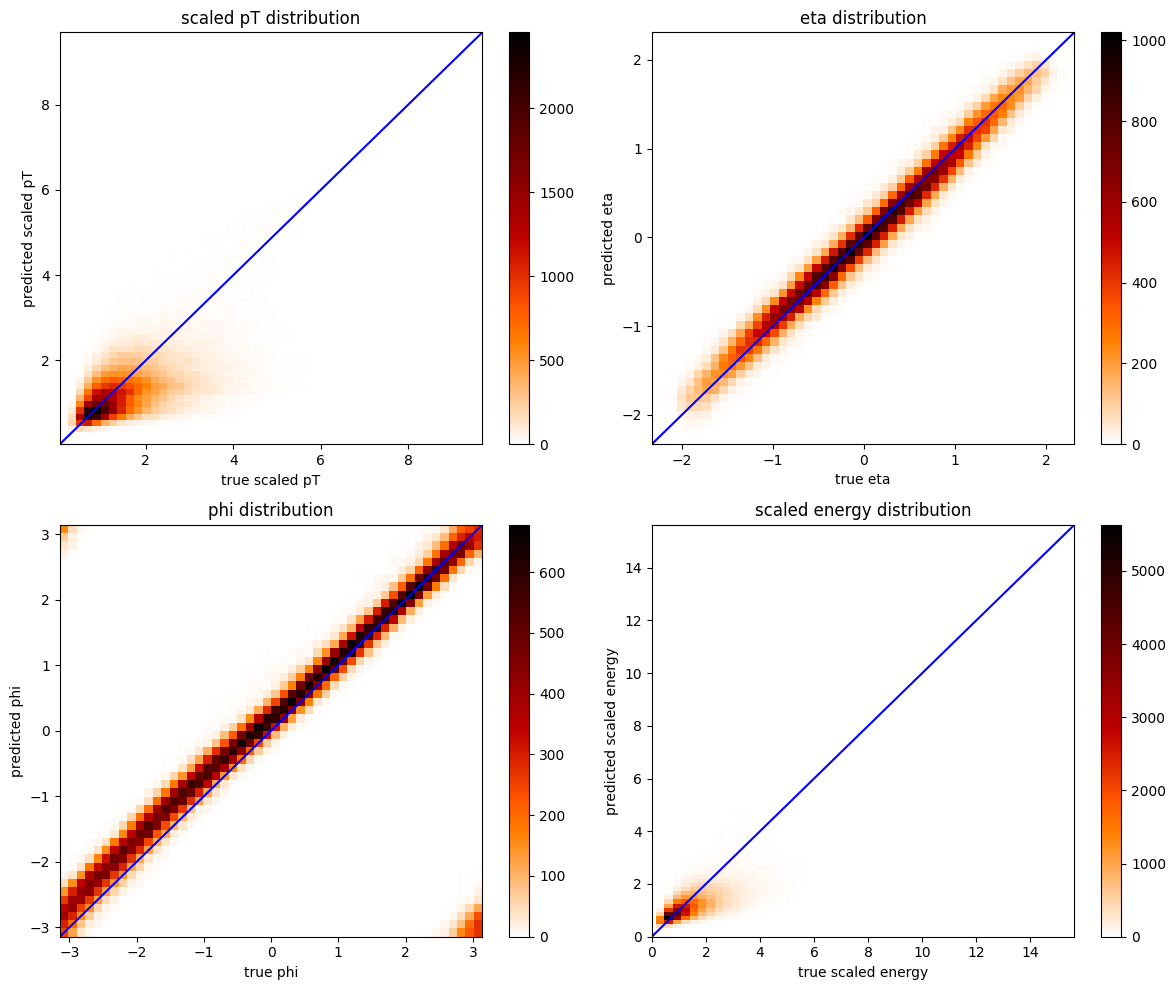

In [17]:
# Evaluate the model on the test set
test_loss, test_metric, y_true, y_pred = trainer.evaluate(plot=plot_particle_reconstruction)

In [18]:
# Label names for classification
labels = [
    "$q/g$",  # 0
    "$H \\to b\\bar{b}$",  # 1
    "$H \\to c\\bar{c}$",  # 2
    "$H \\to gg$",  # 3
    "$H \\to 4q$",  # 4
    "$H \\to \\ell \\nu qq'$",  # 5
    "$Z \\to q\\bar{q}$",  # 6
    "$W \\to qq'$",  # 7
    "$t \\to b\\ell \\nu$",  # 8
    "$t \\to bqq'$"  # 9
]


In [19]:

# Datasets for classification
train_dataset = JetClassDataset(X_train, y_train, normalize, norm_dict, mask_mode=None)
val_dataset = JetClassDataset(X_val, y_val, normalize, norm_dict, mask_mode=None)
test_dataset = JetClassDataset(X_test, y_test, normalize, norm_dict, mask_mode=None)

In [ ]:
from collections import Counter
import numpy as np

def check_uniformity(y, dataset_name, label_names, threshold=0.02):
    """
    Checks if the labels in a dataset are uniformly distributed.
    Supports both integer class arrays and one-hot encoded arrays.
    """
    # If one-hot encoded, convert to class indices
    if len(y.shape) > 1 and y.shape[1] > 1:
        y = np.argmax(y, axis=1)

    total_samples = len(y)
    counts = Counter(y)
    num_classes = len(label_names)
    expected_pct = 1.0 / num_classes

    print(f"--- Distribution for {dataset_name} ({total_samples} samples) ---")

    is_uniform = True
    for idx, name in enumerate(label_names):
        count = counts.get(idx, 0)
        actual_pct = count / total_samples
        print(f"Class {idx} ({name:<18}): {count:<8} | {actual_pct:.2%}")

        # Check if it deviates more than the allowed threshold from absolute uniformity
        if abs(actual_pct - expected_pct) > threshold:
            is_uniform = False

    if is_uniform:
        print(f"✅ {dataset_name} appears to be uniformly distributed (within a {threshold:.1%} tolerance).\n")
    else:
        print(f"⚠️ {dataset_name} is NOT perfectly uniform. Expected around {expected_pct:.2%} per class.\n")

# Run the check on your datasets
# (Using your raw arrays y_train, y_val, and y_test)
check_uniformity(y_train, "Train Dataset", labels)
check_uniformity(y_val, "Validation Dataset", labels)
check_uniformity(y_test, "Test Dataset", labels)

--- Distribution for Train Dataset (800000 samples) ---
Class 0 ($q/g$             ): 80000    | 10.00%
Class 1 ($H \to b\bar{b}$  ): 80000    | 10.00%
Class 2 ($H \to c\bar{c}$  ): 80000    | 10.00%
Class 3 ($H \to gg$        ): 80000    | 10.00%
Class 4 ($H \to 4q$        ): 80000    | 10.00%
Class 5 ($H \to \ell \nu qq'$): 80000    | 10.00%
Class 6 ($Z \to q\bar{q}$  ): 80000    | 10.00%
Class 7 ($W \to qq'$       ): 80000    | 10.00%
Class 8 ($t \to b\ell \nu$ ): 80000    | 10.00%
Class 9 ($t \to bqq'$      ): 80000    | 10.00%
✅ Train Dataset appears to be uniformly distributed (within a 2.0% tolerance).

--- Distribution for Validation Dataset (100000 samples) ---
Class 0 ($q/g$             ): 10000    | 10.00%
Class 1 ($H \to b\bar{b}$  ): 10000    | 10.00%
Class 2 ($H \to c\bar{c}$  ): 10000    | 10.00%
Class 3 ($H \to gg$        ): 10000    | 10.00%
Class 4 ($H \to 4q$        ): 10000    | 10.00%
Class 5 ($H \to \ell \nu qq'$): 10000    | 10.00%
Class 6 ($Z \to q\bar{q}$  ): 1

In [20]:
# Model configurations
pretrained_model_config = LorentzParTConfig(
    num_classes=10,
    embed_dim=128,
    num_heads=8,
    num_layers=8,
    num_cls_layers=2,
    num_mlp_layers=0,
    hidden_dim=256,
    hidden_mv_channels=8,
    in_s_channels=None,
    out_s_channels=None,
    hidden_s_channels=16,
    attention={},
    mlp={},
    dropout=0.1,
    expansion_factor=4,
    max_num_particles=128,
    num_particle_features=4,
    pair_embed_dims=[64, 64, 64],
    weights=gated_pt_path
)

In [21]:
# Initialize the classifier model
pretrained_model = LorentzParT(config=pretrained_model_config).to(device)
pretrained_model

LorentzParT(
  (processor): ParticleProcessor()
  (encoder): LorentzParTEncoder(
    (equilinear): EquiLinear()
    (proj): Linear(in_features=16, out_features=128, bias=True)
    (interaction_embed): InteractionEmbedding(
      (embed): Sequential(
        (0): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (1): Conv1d(4, 64, kernel_size=(1,), stride=(1,))
        (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (3): GELU(approximate='none')
        (4): Conv1d(64, 64, kernel_size=(1,), stride=(1,))
        (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (6): GELU(approximate='none')
        (7): Conv1d(64, 64, kernel_size=(1,), stride=(1,))
        (8): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (9): GELU(approximate='none')
        (10): Conv1d(64, 8, kernel_size=(1,), stride=(1,))
        (11): BatchNorm1d(8, e

In [22]:
# Count parameters in the model
num_params = sum(p.numel() for p in pretrained_model.parameters() if p.requires_grad)
num_params

2282400

In [23]:
# Training configurations
pretrained_config = TrainConfig(
    batch_size=64,
    criterion={
        'name': 'cross_entropy_loss',
        'kwargs': {
            'reduction': 'mean'
        }
    },
    optimizer={
        'name': 'adam',
        'kwargs': {
            'lr': 1e-4
        }
    },
    scheduler={
        'name': 'exponential_lr',
        'kwargs': {
            'gamma': 0.95
        }
    },
    callbacks=[{
        'name': 'early_stopping',
        'kwargs': {
            'monitor': 'val_loss',
            'mode': 'min',
            'patience': 5
        }
    }],
    num_epochs=2,#change
    start_epoch=0,
    logging_dir=str(LOG_DIR),
    logging_steps=1000,
    save_best=True,
    save_ckpt=True,
    save_fig=False,
    device='cuda',
    num_workers=0,
    pin_memory=True
)

In [24]:
# Initialize the trainer
trainer = Trainer(
    model=pretrained_model,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    test_dataset=test_dataset,
    device=device,
    metric=accuracy_metric_ce,
    config=pretrained_config
)

In [25]:
# Train the model
pretrained_history, pretrained_model = trainer.train()

Training:   0%|          | 0/25000 [00:00<?, ?it/s]

step: 1000/25000 | train_loss: 2.0798 | train_metric: 0.1982
step: 2000/25000 | train_loss: 2.0421 | train_metric: 0.2096
step: 3000/25000 | train_loss: 2.0240 | train_metric: 0.2154
step: 4000/25000 | train_loss: 2.0156 | train_metric: 0.2194
step: 5000/25000 | train_loss: 2.0090 | train_metric: 0.2218
step: 6000/25000 | train_loss: 2.0028 | train_metric: 0.2243
step: 7000/25000 | train_loss: 1.9969 | train_metric: 0.2274
step: 8000/25000 | train_loss: 1.9923 | train_metric: 0.2302
step: 9000/25000 | train_loss: 1.9866 | train_metric: 0.2333
step: 10000/25000 | train_loss: 1.9811 | train_metric: 0.2366
step: 11000/25000 | train_loss: 1.9757 | train_metric: 0.2397
step: 12000/25000 | train_loss: 1.9700 | train_metric: 0.2427
epoch: 1/2 | val_loss: 1.9015 | val_metric: 0.2810
step: 13000/25000 | train_loss: 2.0145 | train_metric: 0.2376
step: 14000/25000 | train_loss: 2.0017 | train_metric: 0.2407
step: 15000/25000 | train_loss: 1.9962 | train_metric: 0.2421
step: 16000/25000 | train_lo

In [ ]:
# Train the model
#pretrained_history, pretrained_model = trainer.train()

Training:   0%|          | 0/25000 [00:00<?, ?it/s]

step: 1000/25000 | train_loss: 2.0122 | train_metric: 0.2181
step: 2000/25000 | train_loss: 1.9986 | train_metric: 0.2225
step: 3000/25000 | train_loss: 1.9925 | train_metric: 0.2248
step: 4000/25000 | train_loss: 1.9885 | train_metric: 0.2275
step: 5000/25000 | train_loss: 1.9862 | train_metric: 0.2289
step: 6000/25000 | train_loss: 1.9842 | train_metric: 0.2299
step: 7000/25000 | train_loss: 1.9826 | train_metric: 0.2312
step: 8000/25000 | train_loss: 1.9793 | train_metric: 0.2335
step: 9000/25000 | train_loss: 1.9751 | train_metric: 0.2365
step: 10000/25000 | train_loss: 1.9697 | train_metric: 0.2399
step: 11000/25000 | train_loss: 1.9642 | train_metric: 0.2434
step: 12000/25000 | train_loss: 1.9574 | train_metric: 0.2470
epoch: 1/2 | val_loss: 1.8328 | val_metric: 0.3105
step: 13000/25000 | train_loss: 2.0182 | train_metric: 0.2404
step: 14000/25000 | train_loss: 1.9705 | train_metric: 0.2592
step: 15000/25000 | train_loss: 1.9542 | train_metric: 0.2658
step: 16000/25000 | train_lo

test_loss: 2.1478 | test_metric: 0.1947


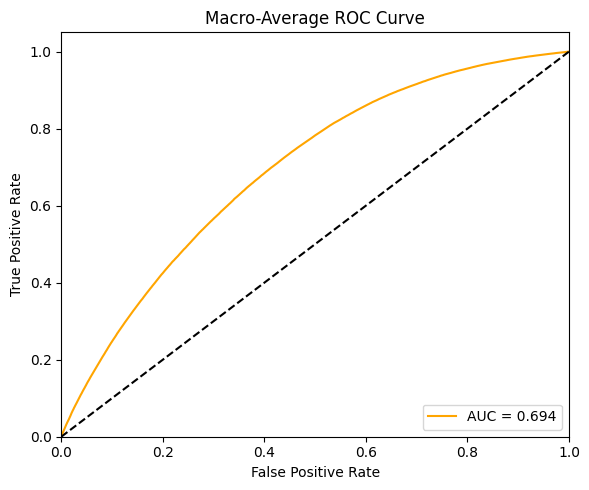

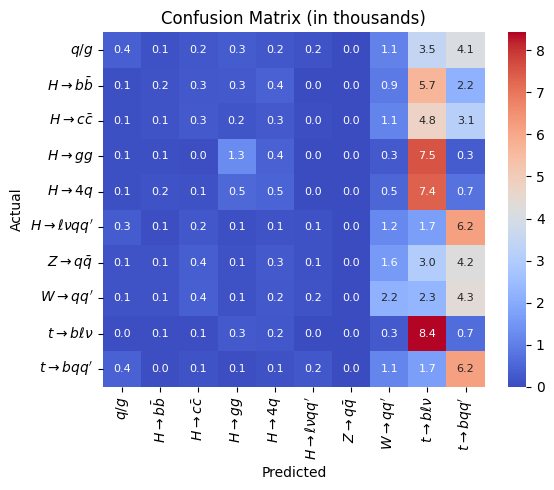

In [26]:
# Evaluate the model on the test set
test_loss, test_metric, y_true, y_pred = trainer.evaluate(
    loss_type='cross_entropy',
    plot=[plot_roc_curve, plot_confusion_matrix]
)